In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Brain Scan Demand Over Time

### Yearly Trend

In [5]:
# Load the yearly sheet
brain_year = pd.read_excel("Final Datasets/brain_scans_10yrs.xlsx", sheet_name="Yearly")

In [6]:
brain_year.head()

,Year,England Population,MRI Scans (NHS),MRI Brain Scans (NHS),MRI Brain %,Private Brain Scans,Total Brain Scans,Clinical Radiologists (NHS),Brain Scan per Radiologist (Annual),Patient Waiting List (MRI),Brain Patients Waiting List,MRI 6+ Week Waiters,Brain 6+ Week Waiters,% Waiting 6+ weeks,Dementia Patients,Brain Tumor Incidence Rate
0,2015/16,54808700,3085065,629050,0.203902,36484.90,665534.90,3932.29566,159.970169,179933,36688.644696,3148,641.882554,0.017495,419073,20.04
1,2016/17,55289000,3358485,686365,0.204367,39809.17,726174.17,4041.32728,169.836530,190534,38938.946850,1329,271.604335,0.006975,436805,20.35
2,2017/18,55619500,3464010,717650,0.207173,41623.70,759273.70,4204.16551,170.699750,197977,41015.526529,3657,757.632354,0.018472,448497,20.65
3,2018/19,55924500,3743995,774845,0.206957,44941.01,819786.01,4384.83746,176.710085,213049,44091.926513,4301,890.120939,0.020188,458562,20.95
4,2019/20,56230100,3811415,802490,0.210549,46544.42,849034.42,4614.89327,173.891345,160852,33867.243919,15710,3307.726369,0.097667,469025,21.26


In [7]:
brain_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 10 non-null     object 
 1   England Population                   10 non-null     int64  
 2   MRI  Scans (NHS)                     10 non-null     int64  
 3   MRI Brain Scans (NHS)                10 non-null     int64  
 4   MRI Brain %                          10 non-null     float64
 5   Private Brain Scans                  10 non-null     float64
 6   Total Brain Scans                    10 non-null     float64
 7   Clinical Radiologists (NHS)          10 non-null     float64
 8   Brain Scan per Radiologist (Annual)  10 non-null     float64
 9   Patient Waiting List (MRI)           10 non-null     int64  
 10  Brain Patients Waiting List          10 non-null     float64
 11  MRI 6+ Week Waiters                

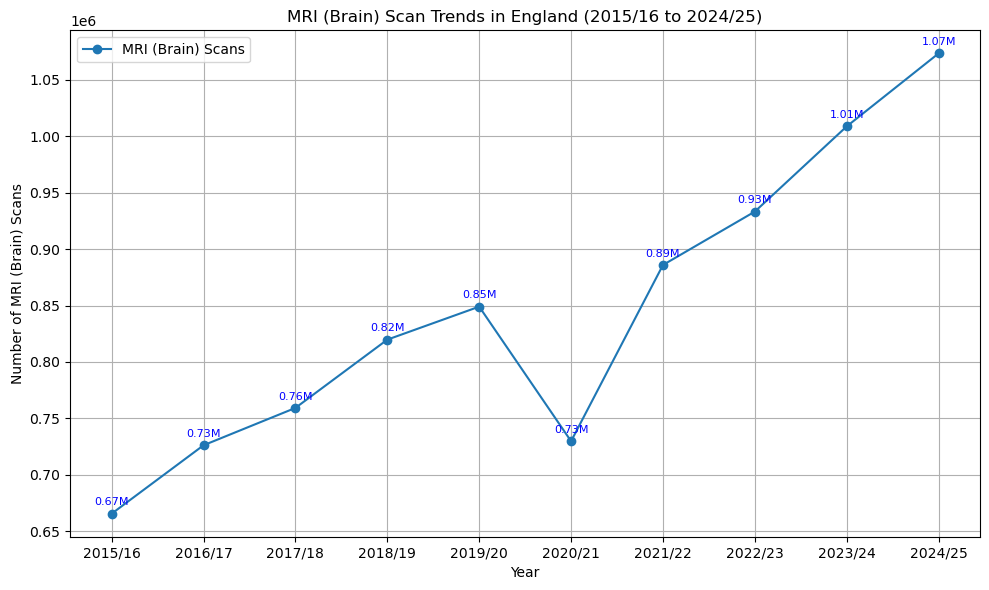

In [8]:
# plotting
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(brain_year["Year"], brain_year['Total Brain Scans'], marker='o', label="MRI (Brain) Scans")

# Annotate each point
for i, val in enumerate(brain_year["Total Brain Scans"]):
    ax.annotate(f"{val/1e6:.2f}M", xy=(i, val), xytext=(0, 6),
                textcoords='offset points', ha='center', fontsize=8, color='blue')

plt.title("MRI (Brain) Scan Trends in England (2015/16 to 2024/25)")
plt.xlabel("Year")
plt.ylabel("Number of MRI (Brain) Scans")
plt.xticks()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
start = brain_year['Total Brain Scans'].iloc[0]   # 2015/16
end = brain_year['Total Brain Scans'].iloc[-1]    # 2024/25
n_years = len(brain_year['Total Brain Scans'])

print(f"Start = {start}")
print(f"End = {end}")
print(f"Years = {n_years}")

Start = 665534.9
End = 1073504.99
Years = 10


In [10]:
# cagr growth
cagr = ((end / start) ** (1/n_years) - 1) * 100
print(f"CAGR (2015/16–2024/25): {cagr:.2f}%")

CAGR (2015/16–2024/25): 4.90%


In [11]:
# 10-year growth
growth = ((end - start) / start) * 100
print(f"10-year brain scan growth = {growth:.1f}%")

10-year brain scan growth = 61.3%


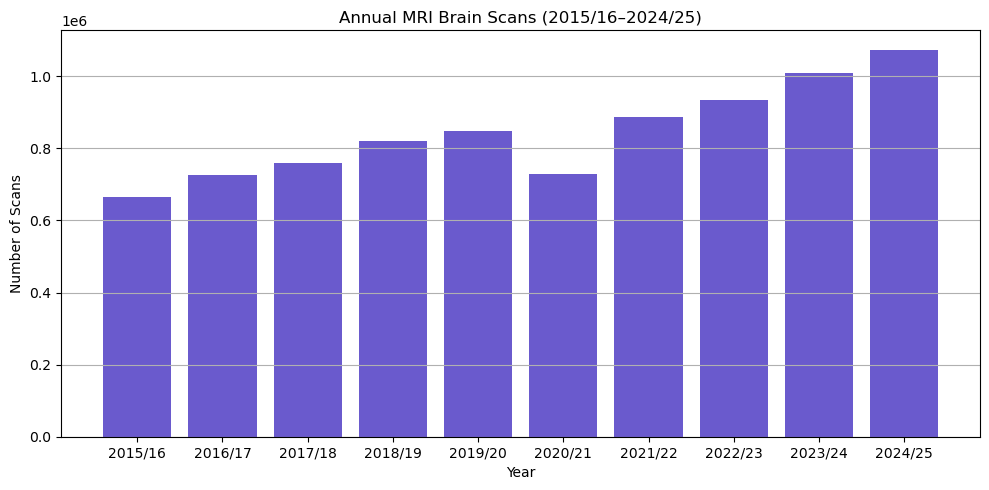

In [12]:
years = brain_year['Year']
values = brain_year['Total Brain Scans']

plt.figure(figsize=(10, 5))
plt.bar(years, values, color='slateblue')
plt.title("Annual MRI Brain Scans (2015/16–2024/25)")
plt.xlabel("Year")
plt.ylabel("Number of Scans")
plt.grid(axis='y')

# ✅ Force all year labels on x-axis
plt.xticks(ticks=years, labels=years)

plt.tight_layout()
plt.show()

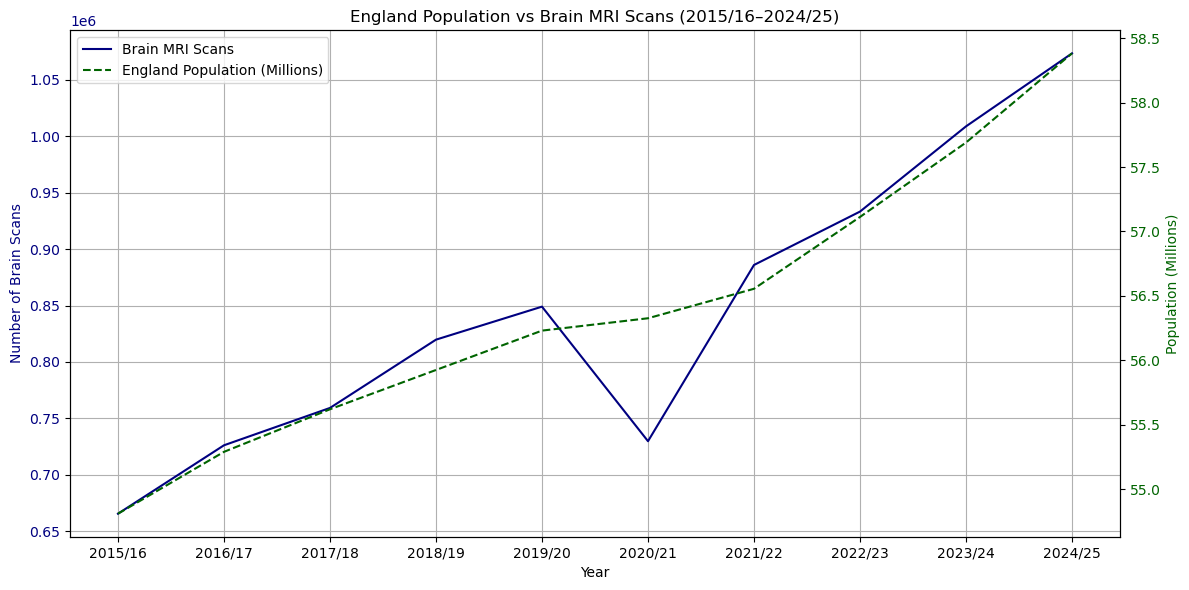

In [13]:
# plot England Population vs Brain MRI Scans
# === Prepare Data ===
scans = brain_year['Total Brain Scans']
population = brain_year['England Population'] / 1_000_000  # Convert to millions
years = brain_year['Year']

# === Plot ===
fig, ax1 = plt.subplots(figsize=(12, 6))

# Line 1: Brain scans (left y-axis)
ax1.plot(years, scans, color='navy', label='Brain MRI Scans')
ax1.set_ylabel('Number of Brain Scans', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

# Line 2: Population (right y-axis)
ax2 = ax1.twinx()
ax2.plot(years, population, color='darkgreen', linestyle='--', label='England Population (Millions)')
ax2.set_ylabel('Population (Millions)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

# Title and grid
plt.title("England Population vs Brain MRI Scans (2015/16–2024/25)")
ax1.set_xlabel("Year")
ax1.grid(True)

# Optional: Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [14]:
population_start = brain_year['England Population'].iloc[0]   # 2015/16
population_end = brain_year['England Population'].iloc[-1]    # 2024/25
n_years = len(brain_year['England Population'])

print(f"Start = {population_start}")
print(f"End = {population_end}")
print(f"Years = {n_years}")

Start = 54808700
End = 58382600
Years = 10


In [15]:
# cagr growth
population_cagr = ((population_end / population_start) ** (1/n_years) - 1) * 100
print(f"CAGR (2015/16–2024/25): {population_cagr:.2f}%")

CAGR (2015/16–2024/25): 0.63%


In [16]:
# 10-year growth
growth = ((population_end - population_start) / population_start) * 100
print(f"10-year England Population growth = {growth:.1f}%")

10-year England Population growth = 6.5%


### Compare Growth Trend

In [17]:
# Select relevant columns and rename for clarity
yearly_df = brain_year[['Year', 'Total Brain Scans', 'England Population', 'Dementia Patients', 'Brain Tumor Incidence Rate']]
yearly_df.columns = ['Year', 'Brain Scans', 'Population', 'Dementia', 'Brain Tumor']

In [18]:
df_norm = yearly_df.copy()
for col in ['Brain Scans', 'Population', 'Dementia', 'Brain Tumor']:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

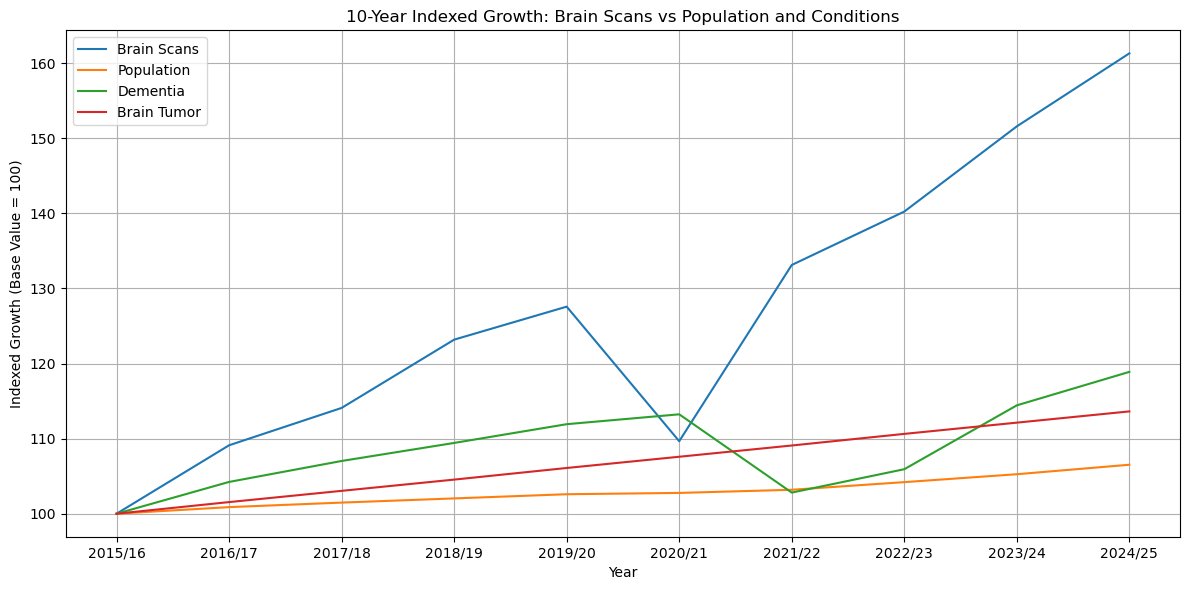

In [19]:
plt.figure(figsize=(12, 6))

for col in ['Brain Scans', 'Population', 'Dementia', 'Brain Tumor']:
    plt.plot(df_norm['Year'], df_norm[col], label=col)

plt.title("10-Year Indexed Growth: Brain Scans vs Population and Conditions")
plt.xlabel("Year")
plt.ylabel("Indexed Growth (Base Value = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Monthly Trend

In [20]:
# === Step 1: Load your Excel file ===
file_path = "Final Datasets/brain_scans_10yrs.xlsx"
brain_ts = pd.read_excel(file_path, sheet_name="Monthly")

In [21]:
brain_ts.head()

,Date,England Population,MRI Scans (NHS),MRI Brain Scans (NHS),MRI Brain %,Private Brain Scans,Total Brain Scans,Clinical Radiologists,Brain Scan per Radiologist (Monthly),Patient Waiting List (MRI),Brain Patients Waiting List,MRI 6+ Week Waiter,Brain 6+ Week Waiters,% Waiting 6+ weeks,Dementia Patients,Brain Tumor Incidence Rate
0,2015-04-01,54808700,238620,49395,0.207003,2864.91,52259.91,3760.50487,13.135204,164838,34121.921926,1574,325.822354,0.009549,410124,20.04
1,2015-05-01,54808700,239170,48740,0.203788,2826.92,51566.92,3766.88787,12.939063,164769,33577.961534,1718,350.107957,0.010427,396723,20.04
2,2015-06-01,54808700,252965,52060,0.205799,3019.48,55079.48,3770.97512,13.805448,174601,35932.749827,1779,366.116815,0.010189,417814,20.04
3,2015-07-01,54808700,270940,54055,0.199509,3135.19,57190.19,3767.60387,14.347315,178862,35684.599579,1598,318.815568,0.008934,418473,20.04
4,2015-08-01,54808700,249925,50330,0.201380,2919.14,53249.14,3860.73296,13.036385,161620,32547.102531,2040,410.816045,0.012622,402525,20.04


In [22]:
brain_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  120 non-null    datetime64[ns]
 1   England Population                    120 non-null    int64         
 2   MRI Scans (NHS)                       120 non-null    int64         
 3   MRI Brain Scans (NHS)                 120 non-null    int64         
 4   MRI Brain %                           120 non-null    float64       
 5   Private Brain Scans                   120 non-null    float64       
 6   Total Brain Scans                     120 non-null    float64       
 7   Clinical Radiologists                 120 non-null    float64       
 8   Brain Scan per Radiologist (Monthly)  120 non-null    float64       
 9   Patient Waiting List (MRI)            120 non-null    int64         
 10  Br

In [23]:
# === Step 2: Convert 'Date' to datetime format ===
brain_ts['Date'] = pd.to_datetime(brain_ts['Date'], dayfirst=True)

In [24]:
# === Step 3: Set Date as index and sort by time ===
brain_ts = brain_ts.set_index('Date').sort_index()

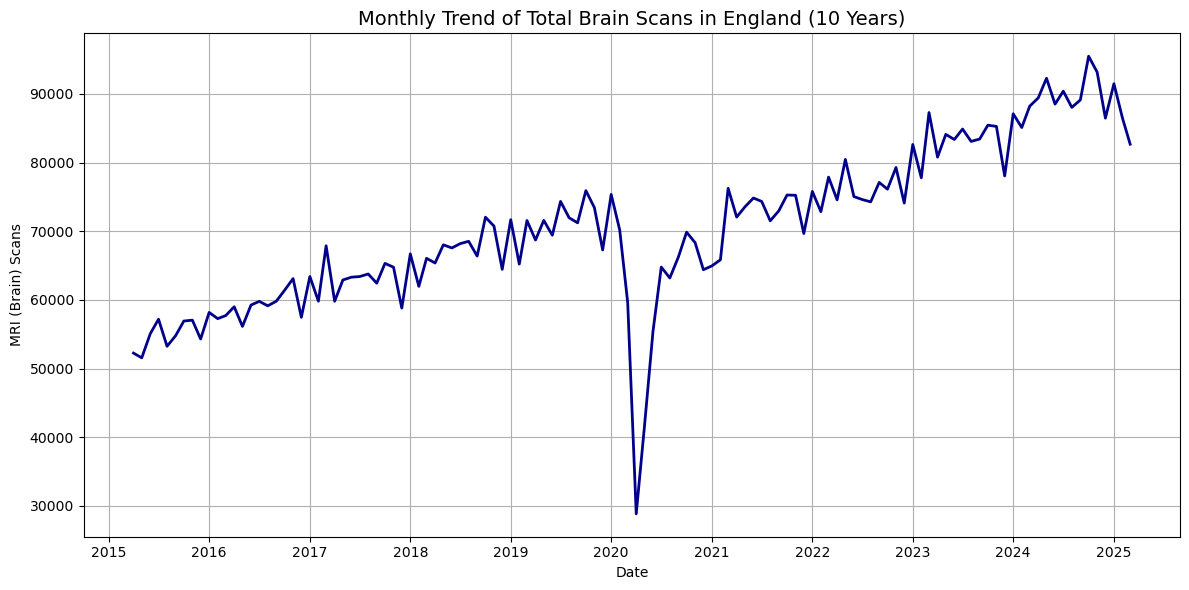

In [25]:
# === Step 4: Plot monthly trend ===
plt.figure(figsize=(12, 6))
plt.plot(brain_ts.index, brain_ts['Total Brain Scans'], color='darkblue', linewidth=2)

# === Step 5: Add labels and formatting ===
plt.title('Monthly Trend of Total Brain Scans in England (10 Years)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('MRI (Brain) Scans')
plt.grid(True)
plt.tight_layout()
plt.show()

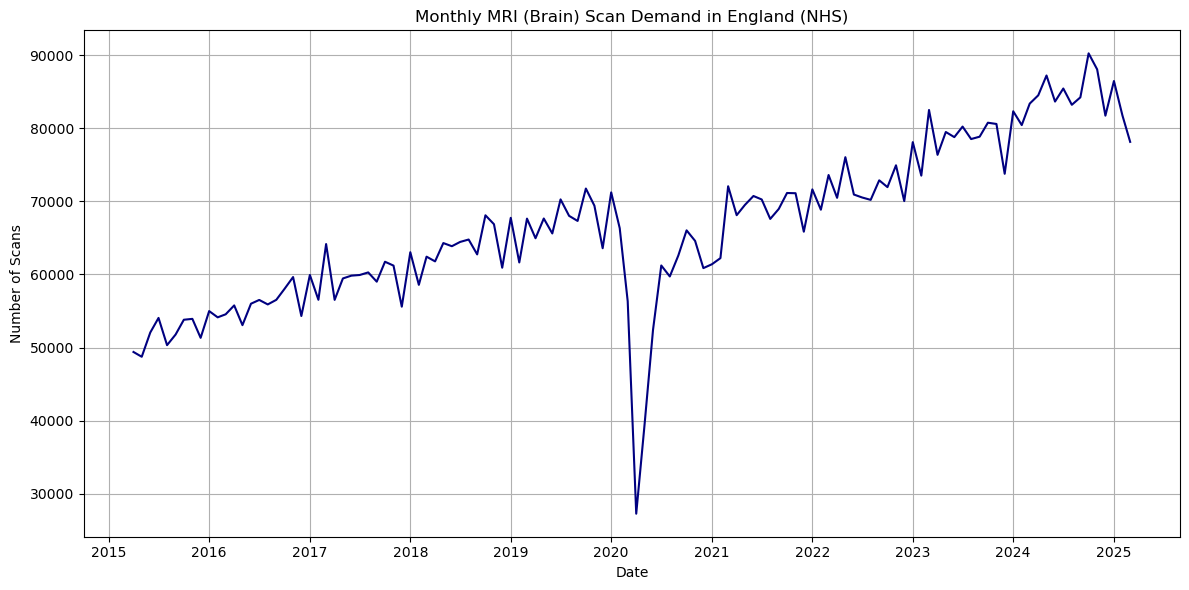

In [27]:
# NHS Brain Scan Demand Over Time
file_path = "Final Datasets/brain_scans_10yrs.xlsx"
df_monthly = pd.read_excel(file_path, sheet_name="Monthly")

df_monthly['Date'] = pd.to_datetime(df_monthly['Date'])

plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Date'], df_monthly['MRI Brain Scans (NHS)'], label='Brain MRI Scans', color='navy')
plt.title("Monthly MRI (Brain) Scan Demand in England (NHS)")
plt.xlabel("Date")
plt.ylabel("Number of Scans")
plt.grid(True)
plt.tight_layout()
plt.show()

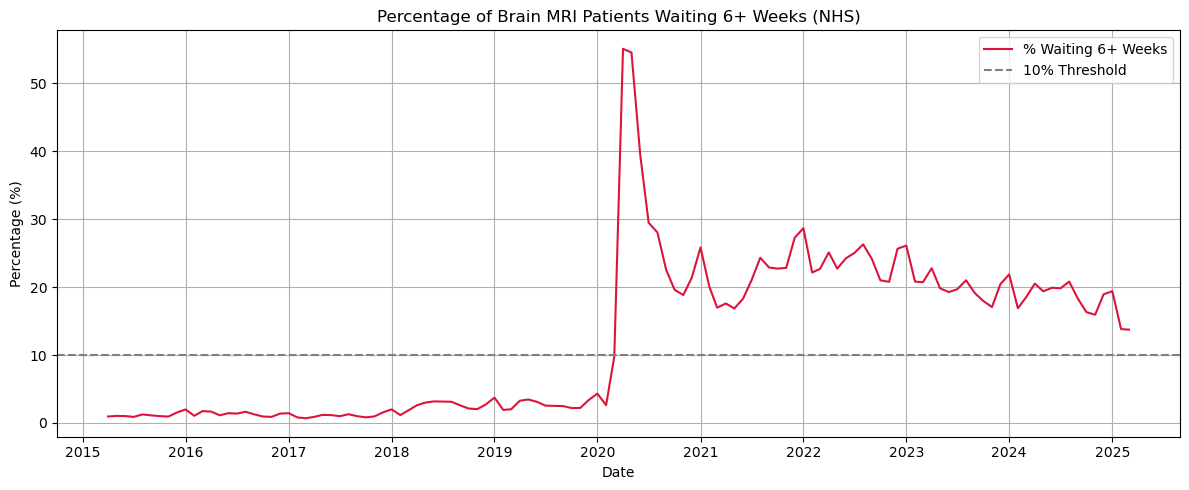

In [28]:
# % of Brain Scan Patients Waiting >6 Weeks
plt.figure(figsize=(12, 5))
plt.plot(df_monthly['Date'], df_monthly['% Waiting 6+ weeks'] * 100, color='crimson', label='% Waiting 6+ Weeks')
plt.axhline(10, color='gray', linestyle='--', label='10% Threshold')
plt.title("Percentage of Brain MRI Patients Waiting 6+ Weeks (NHS)")
plt.xlabel("Date")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

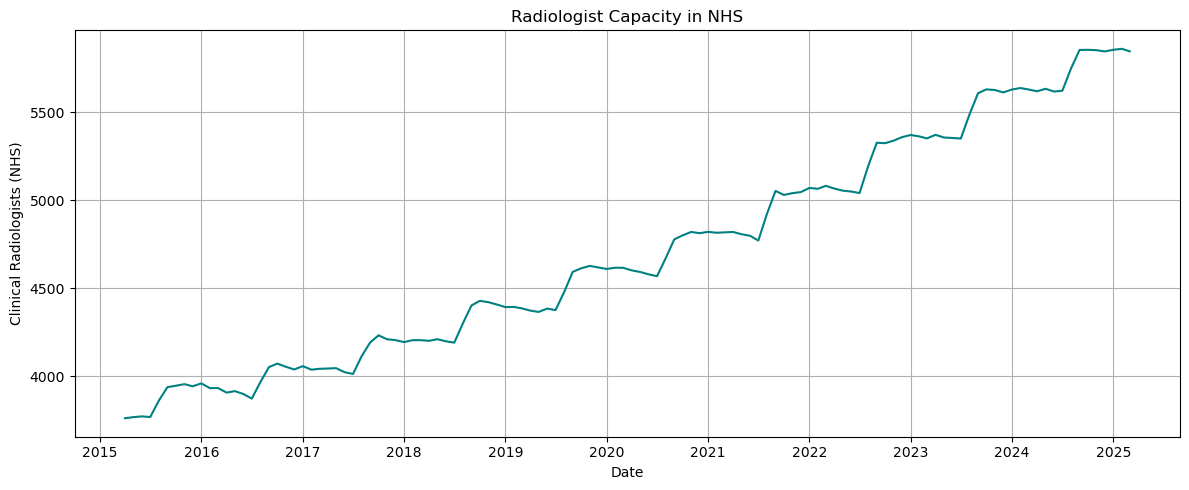

In [29]:
# Radiologist capacity (Monthly)
plt.figure(figsize=(12, 5))
plt.plot(df_monthly['Date'], df_monthly['Clinical Radiologists'], color='teal')
plt.title("Radiologist Capacity in NHS")
plt.xlabel("Date")
plt.ylabel("Clinical Radiologists (NHS)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# cagr growth
radiologist_cagr = ((5845 / 3932) ** (1/10) - 1) * 100
print(f"CAGR (2015/16–2024/25): {radiologist_cagr:.2f}%")

CAGR (2015/16–2024/25): 4.04%


In [31]:
# 10-year growth
growth = ((5845 - 3932) / 3932) * 100
print(f"10-year radiologist growth = {growth:.1f}%")

10-year radiologist growth = 48.7%


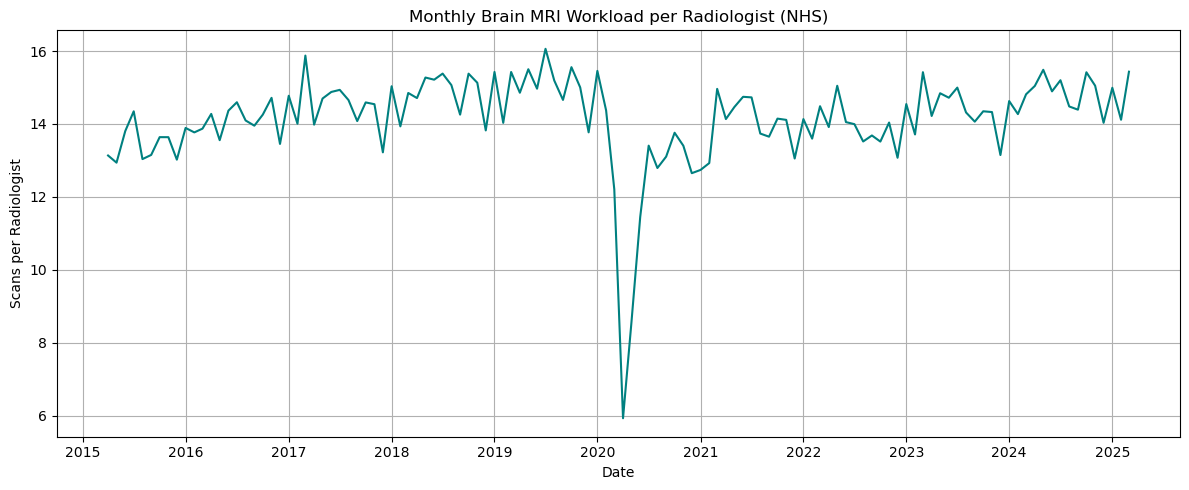

In [32]:
# Radiologist Workload on Brain MRI (Monthly)
plt.figure(figsize=(12, 5))
plt.plot(df_monthly['Date'], df_monthly['Brain Scan per Radiologist (Monthly)'], color='teal')
plt.title("Monthly Brain MRI Workload per Radiologist (NHS)")
plt.xlabel("Date")
plt.ylabel("Scans per Radiologist")
plt.grid(True)
plt.tight_layout()
plt.show()

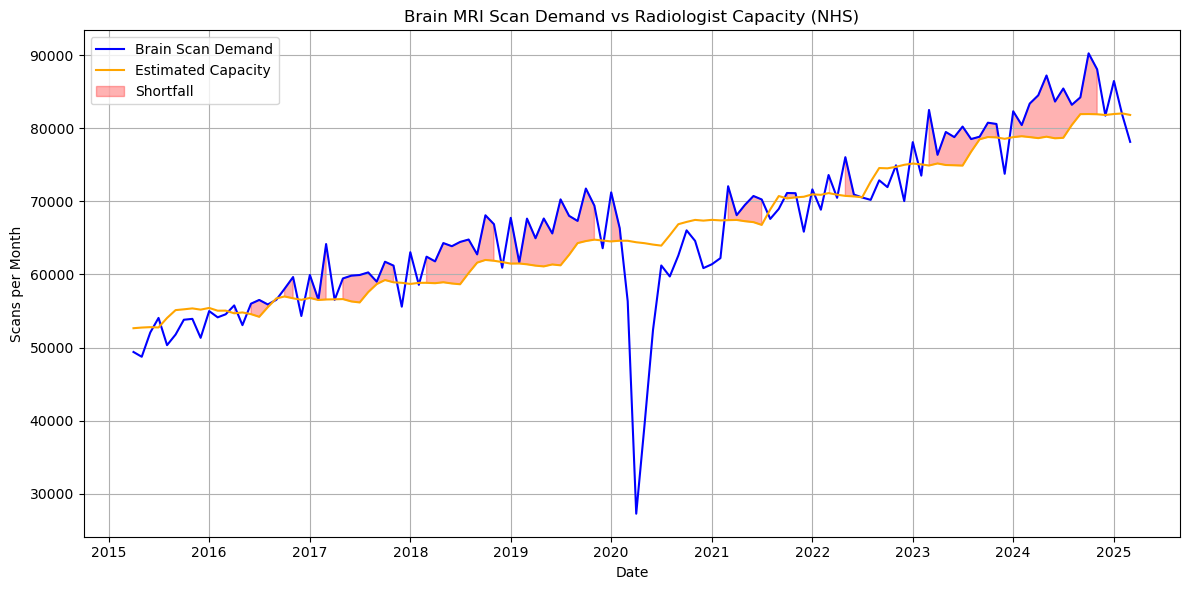

In [33]:
# Scan Demand vs Capacity (Estimated)
# Estimate national capacity (if 1 radiologist reads 167 brain scans/year → ~14/month)
capacity = df_monthly['Clinical Radiologists'] * 14

plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Date'], df_monthly['MRI Brain Scans (NHS)'], label='Brain Scan Demand', color='blue')
plt.plot(df_monthly['Date'], capacity, label='Estimated Capacity', color='orange')
plt.fill_between(df_monthly['Date'], capacity, df_monthly['MRI Brain Scans (NHS)'],
                 where=(df_monthly['MRI Brain Scans (NHS)'] > capacity), color='red', alpha=0.3, label='Shortfall')
plt.title("Brain MRI Scan Demand vs Radiologist Capacity (NHS)")
plt.xlabel("Date")
plt.ylabel("Scans per Month")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

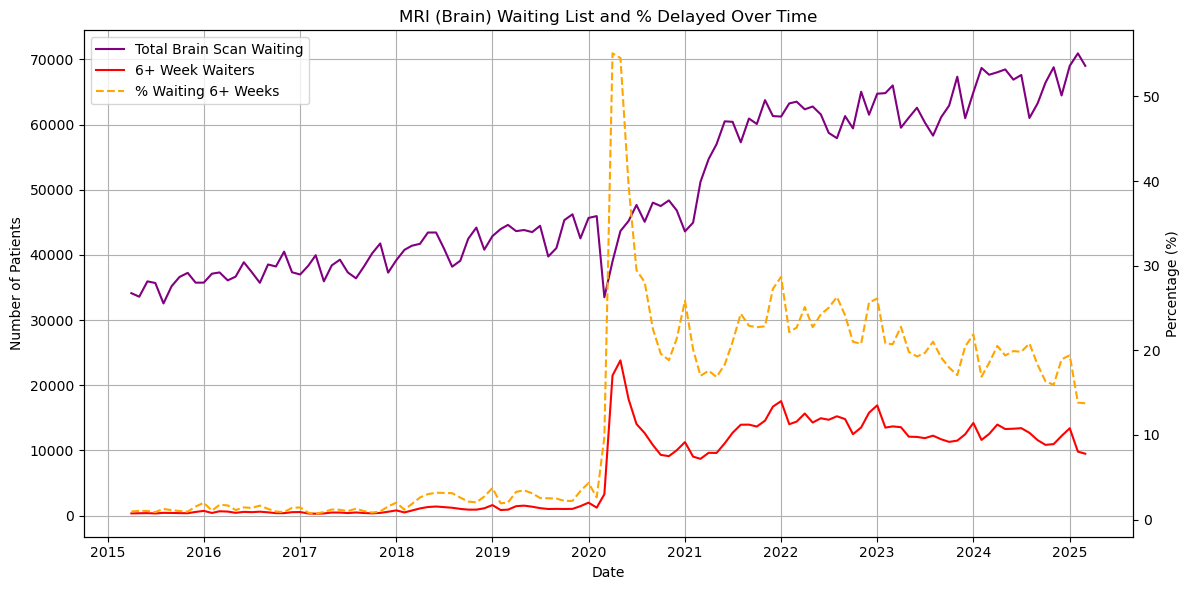

In [34]:
# Waiting List Growth Over Time
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: absolute numbers
ax1.plot(df_monthly['Date'], df_monthly['Brain Patients Waiting List'], label='Total Brain Scan Waiting', color='purple')
ax1.plot(df_monthly['Date'], df_monthly['Brain 6+ Week Waiters'], label='6+ Week Waiters', color='red')
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Patients")
ax1.grid(True)

# Secondary y-axis: percentage
ax2 = ax1.twinx()
ax2.plot(df_monthly['Date'], df_monthly['% Waiting 6+ weeks'] * 100, label='% Waiting 6+ Weeks', color='orange', linestyle='--')
ax2.set_ylabel("Percentage (%)")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title("MRI (Brain) Waiting List and % Delayed Over Time")
plt.tight_layout()
plt.show()

## Dementia Trend

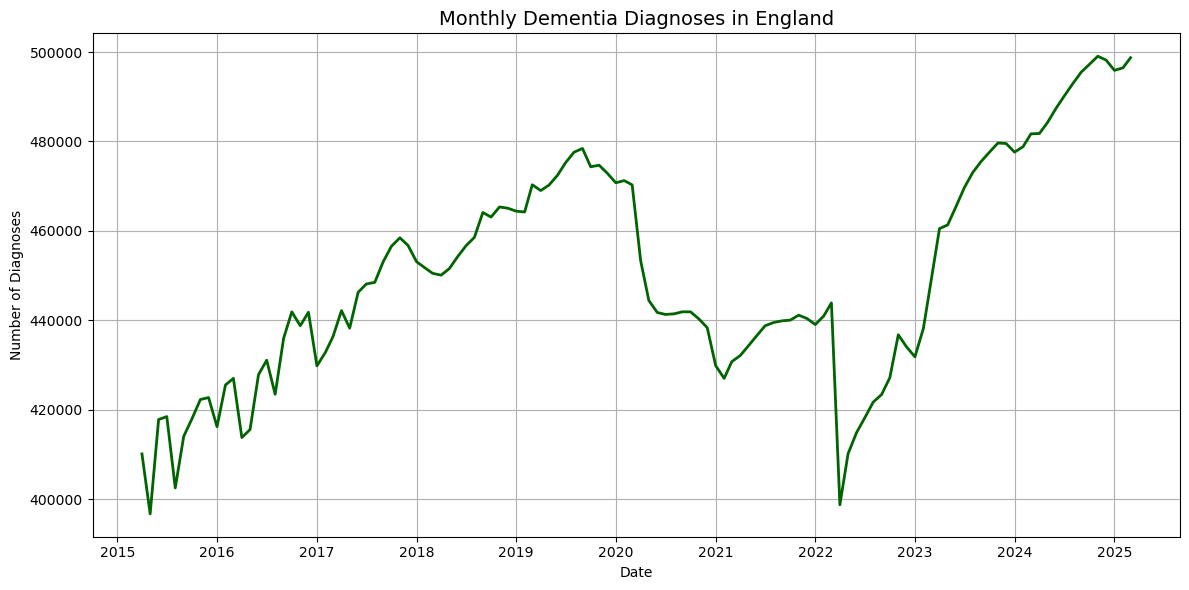

In [35]:
# === Step 1: Load your Excel file ===
file_path = "Final Datasets/brain_scans_10yrs.xlsx"
dementia = pd.read_excel(file_path, sheet_name="Monthly")

# === Step 2: Ensure datetime format ===
dementia['Date'] = pd.to_datetime(dementia['Date'])

# === Step 3: Clean and convert dementia column
dementia['Dementia Patients'] = dementia['Dementia Patients'].replace({',': ''}, regex=True).astype(float)

# === Step 4: Plot trend ===
plt.figure(figsize=(12, 6))
plt.plot(dementia['Date'], dementia['Dementia Patients'], color='darkgreen', linewidth=2)
plt.title("Monthly Dementia Diagnoses in England", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Diagnoses")
plt.grid(True)
plt.tight_layout()
plt.show()

## Brain Tumor

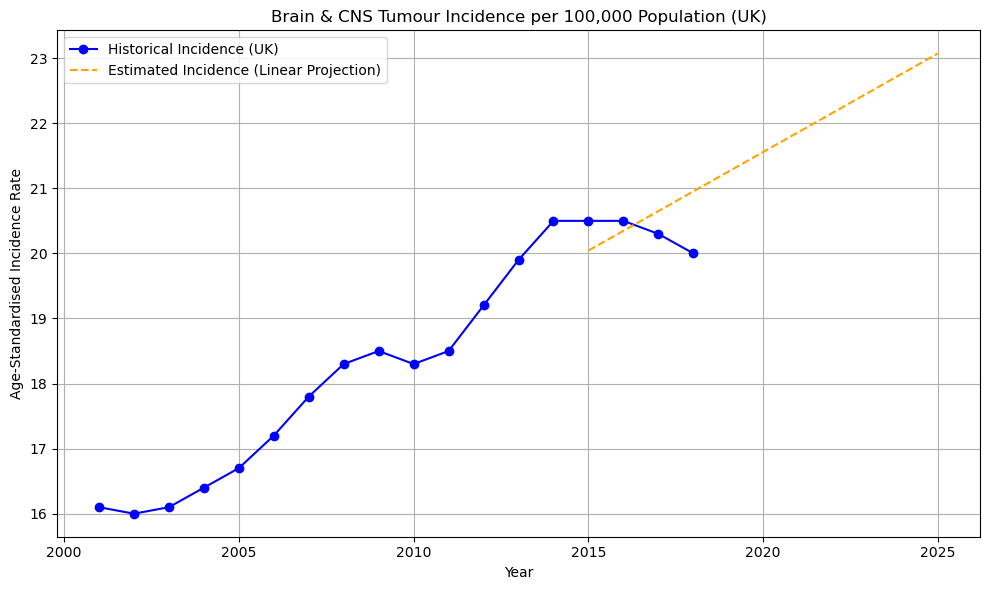

In [38]:
# Example years and incidence rates
years = np.array(range(2001, 2019)).reshape(-1, 1)
rates = np.array([16.1, 16.0, 16.1, 16.4, 16.7, 17.2, 17.8, 18.3, 18.5, 18.3, 18.5, 19.2, 19.9, 20.5, 20.5, 20.5, 20.3, 20.0])

# === Step 2: Fit a linear regression model ===
model = LinearRegression()
model.fit(years.reshape(-1, 1), rates)

# === Step 3: Forecast 2015–2025 ===
forecast_years = np.array(range(2015, 2026))
forecast_rates = model.predict(forecast_years.reshape(-1, 1))

# === Step 4: Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, rates, label="Historical Incidence (UK)", marker='o', color='blue')
plt.plot(forecast_years, forecast_rates, label="Estimated Incidence (Linear Projection)", linestyle='--', color='orange')

plt.title("Brain & CNS Tumour Incidence per 100,000 Population (UK)")
plt.xlabel("Year")
plt.ylabel("Age-Standardised Incidence Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# === Step 4: Create a table
df_forecast = pd.DataFrame({
    "Year": forecast_years,
    "Projected Incidence Rate (per 100,000)": np.round(forecast_rates, 2)
})

# === Step 5: Display the table
print(df_forecast)

    Year  Projected Incidence Rate (per 100,000)
0   2015                                   20.04
1   2016                                   20.35
2   2017                                   20.65
3   2018                                   20.95
4   2019                                   21.26
5   2020                                   21.56
6   2021                                   21.86
7   2022                                   22.17
8   2023                                   22.47
9   2024                                   22.77
10  2025                                   23.07
